# Model Evaluation

This notebook evaluates the trained Hybrid Autoencoder + ResNet18 model.

In [1]:
import os
import json
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import sys
sys.path.append('../src')
from model import HybridCovidModel
from preprocess import get_dataloaders
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

try:
    import torch_xla.core.xla_model as xm
    device = xm.xla_device()
    print(f"Device: TPU ({device})")
except ImportError:
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Device: {device}")

Device: cpu


## Training Curves

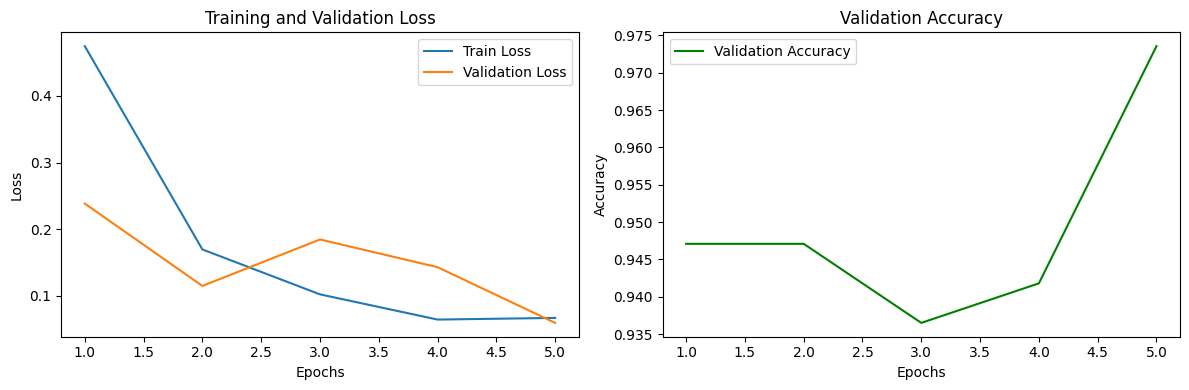

In [2]:
history_path = '../models/metrics_history.json'
if os.path.exists(history_path):
    with open(history_path, 'r') as f:
        history = json.load(f)

    epochs = range(1, len(history['train_loss']) + 1)
    
    plt.figure(figsize=(12, 4))
    
    # Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], label='Train Loss')
    plt.plot(epochs, history['val_loss'], label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    
    # Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['val_acc'], label='Validation Accuracy', color='green')
    plt.title('Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    
    plt.tight_layout()
    plt.show()
else:
    print("Metrics history not found. Train the model first.")

## Confusion Matrix & Metrics

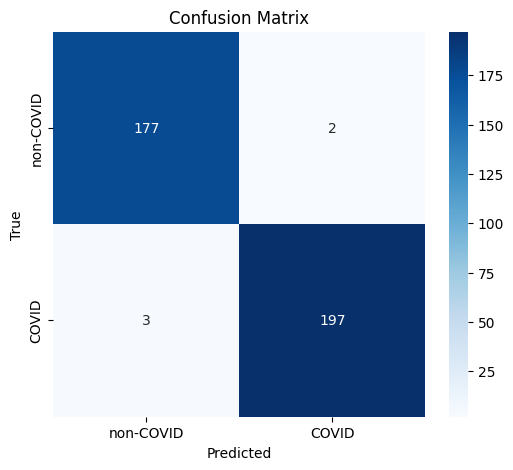


Classification Report:
              precision    recall  f1-score   support

   non-COVID       0.98      0.99      0.99       179
       COVID       0.99      0.98      0.99       200

    accuracy                           0.99       379
   macro avg       0.99      0.99      0.99       379
weighted avg       0.99      0.99      0.99       379



In [4]:
model_path = '../models/best_model.pth'
data_dir = '../data'

if os.path.exists(model_path) and os.path.exists(data_dir):
    model = HybridCovidModel()
    model.load_state_dict(torch.load(model_path, map_location=device))
    model = model.to(device)
    model.eval()

    _, _, test_loader = get_dataloaders(data_dir, batch_size=16)

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            out, _ = model(images)
            probs = torch.sigmoid(out)
            preds = (probs > 0.5).float()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['non-COVID', 'COVID'], yticklabels=['non-COVID', 'COVID'])
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()
    
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=['non-COVID', 'COVID']))
else:
    print("Model or Data not found. Please ensure the model is trained and data is available.")